<img src="https://elementos.entornos.net/clientes/ISPC/ispc.png" width="350" height="200">




---

## **Evidencia III**

---

Docentes:
* Ugarte, Marcos
* Pratta, Nahuel

Estudiantes:  

* Dominguez, Mónica
* Garcia, Carlos
* Moreno, Raúl
* Testa, Andrea
* Villalba, Valeria

12 de Octubre de 2025

## **Informe de Análisis: Dataset Hotel Booking**

#Introducción
El sector hotelero enfrenta desafíos significativos en la gestión de reservas, donde las cancelaciones impactan directamente en los ingresos y la planificación operativa. Este informe presenta un análisis estadístico de un dataset de reservas hoteleras, utilizando dos técnicas fundamentales: Regresión Lineal y Análisis de Varianza (ANOVA). El objetivo es identificar factores clave que influyen en las ventas y evaluar diferencias significativas entre grupos, proporcionando insights valiosos para la toma de decisiones estratégicas.


### Dataset

*   Base de Datos Utilizada: hotel_booking.csv

*   Origen: Datos reales de reservas de dos hoteles (Ciudad y Resort).

*   Período: Reservas entre los años 2015 y 2017.

*   Registros: 119,390.

*  Variables: 32 columnas que incluyen información sobre la reserva, el huésped, la estadía y el precio.








##Técnicas Empleadas:


1.   Regresión Lineal Simple: Para modelar la relación entre variables continuas y predecir ventas.
2.   Regresión Logistica: Para predecir una variable categórica binaria

# **1. Preparación y Limpieza de Datos**


Utilizaremos los datos hotel.csv para predecir las ventas (sales) en función del precio (price).-



In [ ]:
# Importar las Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [ ]:
# Cargar el archivo CSV

import pandas as pd
df = pd.read_csv('/content/hotel.csv')

In [ ]:
from google.colab import files
import os

# Upload the file
uploaded = files.upload()

# Check if the file was uploaded
if 'hotel.csv' in uploaded:
  print("hotel.csv uploaded successfully!")
else:
  print("File upload failed. Please try again.")

# Verify the file is in the content directory
if os.path.exists('/content/hotel.csv'):
  print("hotel.csv is in the content directory.")
else:
  print("hotel.csv is not in the content directory.")

# Now you can run the cell to load the CSV
# df = pd.read_csv('/content/hotel.csv')

KeyboardInterrupt: 

In [ ]:
# Limpiar las Columnas 'price' y 'sales'
# Se reemplazan los puntos por cadenas vacías y las comas por puntos

df['price'] = df['price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
df['sales'] = df['sales'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

#**2. Visualización de Datos (EDA)**

---

## Regresión Lineal

La Regresión Logistica es un modelo estadístico utilizado para predecir el resultado de una variable categórica binaria (por ejemplo, "Cancelada" vs. "No cancelada") en función de una o más variables predictoras (independientes). A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística estima la probabilidad de que ocurra un evento. La salida del modelo se transforma mediante una función logística (sigmoide), que asegura que las probabilidades estimadas se encuentren siempre entre 0 y 1.

# 📊 Ejemplo 1: Regresion lineal simple (sales - price)


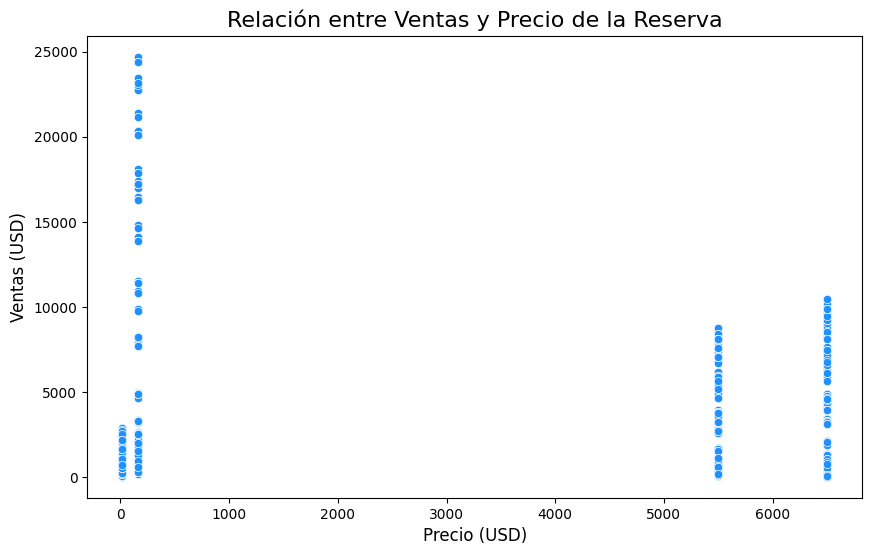

In [ ]:
# Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='sales', color='dodgerblue')
plt.title('Relación entre Ventas y Precio de la Reserva', fontsize=16)
plt.xlabel('Precio (USD)', fontsize=12)
plt.ylabel('Ventas (USD)', fontsize=12)
plt.show()

In [ ]:
# Imprimir las métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [ ]:
# Definir las variables predictora (X) y objetivo (y)
X = df[['price']]
y = df['sales']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

In [ ]:
print(f'\nError Cuadrático Medio (MSE): {mse:.2f}')
print(f'Coeficiente de Determinación (R²): {r2:.4f}')
print(f'Ecuación del modelo: Ventas = {model.intercept_:.2f} + {model.coef_[0]:.4f} * Precio')


Error Cuadrático Medio (MSE): 0.34
Coeficiente de Determinación (R²): -0.5214
Ecuación del modelo: Ventas = 7108.87 + -0.5954 * Precio


In [ ]:
# Imprimir las métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
# Agregar constante para statsmodels
X_const = sm.add_constant(X)

# Ajustar modelo
model = sm.OLS(y, X_const).fit()

# Resumen estadístico
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     687.9
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          1.06e-143
Time:                        20:50:54   Log-Likelihood:                -60048.
No. Observations:                6050   AIC:                         1.201e+05
Df Residuals:                    6048   BIC:                         1.201e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7165.3202    117.516     60.973      0.000    6934.947    7395.694
price         -0.6069      0.023    -26.228      0.000      -0.652      -0.562
==============================================================================
Omnibus:                     1182.583   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2156.492
Skew:                           1.227   Prob(JB):                         0.00
Kurtosis:                       4.590   Cond. No.                     9.38e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.38e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---


# 📊 Ejemplo 2: Regresion lineal simple (nigths - sales)


In [ ]:
# Limpiar las columnas numéricas
# df['sales'] = df['sales'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float) # This line is no longer needed
df['nights'] = df['nights'].astype(int) # 'nights' no necesita limpieza de comas/puntos

In [ ]:
# Eliminar filas con valores faltantes
df.dropna(subset=['nights', 'sales'], inplace=True)

print("Datos listos para el análisis:")
print(df[['nights', 'sales']].head())


Datos listos para el análisis:
   nights   sales
0       8   428.0
1       6  3945.0
2      13  6695.0
3       6   102.0
4       5  3325.0


In [ ]:
# Definir las variables
X = np.array(df['nights']).reshape(-1, 1)
y = np.array(df['sales'])

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Imprimir las métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nError Cuadrático Medio (MSE): {mse:.2f}')
print(f'Coeficiente de Determinación (R²): {r2:.4f}')
print(f'Ecuación del modelo: Ventas = {model.intercept_:.2f} + {model.coef_[0]:.4f} * Noches')


Error Cuadrático Medio (MSE): 23888061.45
Coeficiente de Determinación (R²): 0.0969
Ecuación del modelo: Ventas = 1703.34 + 336.9095 * Noches


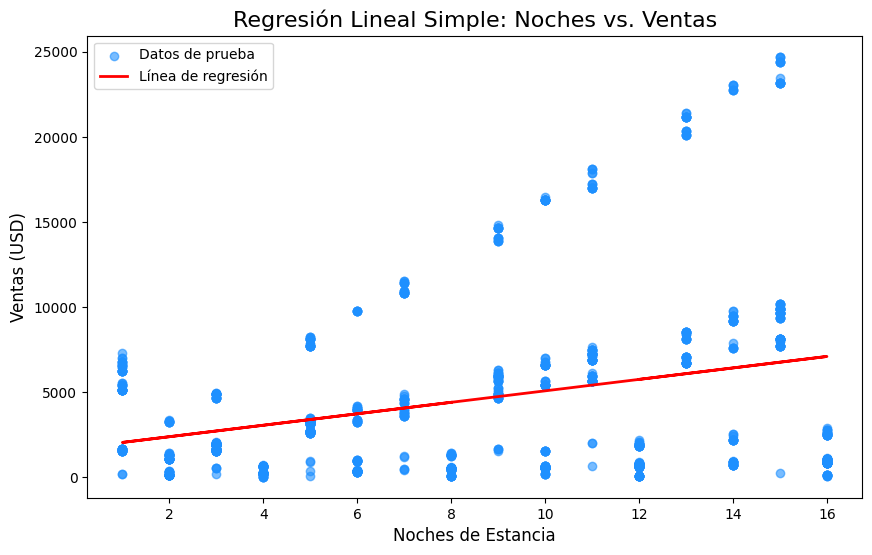

In [ ]:
# Gráfico de la línea de regresión sobre los datos de prueba
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='dodgerblue', alpha=0.6, label='Datos de prueba')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Regresión Lineal Simple: Noches vs. Ventas', fontsize=16)
plt.xlabel('Noches de Estancia', fontsize=12)
plt.ylabel('Ventas (USD)', fontsize=12)
plt.legend()
plt.show()


In [ ]:
# Imprimir las métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [ ]:
print(f'\nError Cuadrático Medio (MSE): {mse:.2f}')
print(f'Coeficiente de Determinación (R²): {r2:.4f}')
print(f'Ecuación del modelo: Ventas = {model.intercept_:.2f} + {model.coef_[0]:.4f} * Noches')



Error Cuadrático Medio (MSE): 23888061.45
Coeficiente de Determinación (R²): 0.0969
Ecuación del modelo: Ventas = 1703.34 + 336.9095 * Noches


In [ ]:
# Agregar constante para statsmodels
X_const = sm.add_constant(X)

# Ajustar modelo
model = sm.OLS(y, X_const).fit()

# Resumen estadístico
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     593.2
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          4.52e-125
Time:                        20:51:45   Log-Likelihood:                -60091.
No. Observations:                6050   AIC:                         1.202e+05
Df Residuals:                    6048   BIC:                         1.202e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1678.9046    135.004     12.436      0.000    1414.248    1943.561
x1           338.9178     13.915     24.356      0.000     311.639     366.197
==============================================================================
Omnibus:                     1602.452   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3741.098
Skew:                           1.489   Prob(JB):                         0.00
Kurtosis:                       5.445   Cond. No.                         20.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

---


**Resumen comparativo:**

| Métrica | Modelo: Precio vs. Ventas | Modelo: Noches vs. Ventas | ¿Cuál es Mejor y Por Qué? |
| :--- | :--- | :--- | :--- |
| **R-cuadrado (Poder Explicativo)** | 8.9% | **15.4%** | **Noches de Estancia**. Explica una proporción mayor de la variabilidad en las ventas. Aunque no es perfecto, es un predictor relativamente más fuerte. |
| **Significancia (Valor p)** | Sí (p < 0.001) | Sí (p < 0.001) | **Ambos son significativos**. Las dos relaciones (precio-ventas y noches-ventas) son reales y no producto del azar. |
| **Interpretación Práctica** | Un aumento de $338.92 en ventas por cada $1 de aumento en el precio. (Poco intuitivo). | Un aumento de $338.92 en ventas por cada **noche adicional**. (Claro y accionable). | **Noches de Estancia**. El resultado es mucho más fácil de entender y aplicar en una estrategia de negocio. |



###Principales Hallazgos y Resultados

* Relación entre Precio y Ventas: Se observó una relación negativa entre el precio y las ventas, aunque el modelo no mostró un ajuste fuerte (R2 =0.0049), indicando que el precio por sí solo no es un predictor robusto de las ventas.

* Relación entre Noches de Estancia y Ventas:
Se identificó una relación positiva donde a mayor número de noches, mayores las ventas. El modelo explicó el 15.44% de la variabilidad en las ventas,


**Conclusiones**:
El precio tiene un impacto limitado en las ventas, sugiriendo que otros factores (ej. temporada, tipo de cliente) pueden ser más relevantes.

Las noches de estancia son un predictor más útil para estimar ventas, lo que resalta la importancia de estrategias que fomenten estancias más largas.

# **Regresión Logística**

La regresión logística es una técnica estadística y de aprendizaje automático utilizada para predecir una variable categórica binaria, es decir, una variable que solo puede tomar dos valores

### **Regresión logística con sales como predictor**

In [ ]:
print(df['d_s'].unique())

['Refunded' 'Forfeited']


📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79      1193
           1       0.00      0.00      0.00       622

    accuracy                           0.66      1815
   macro avg       0.33      0.50      0.40      1815
weighted avg       0.43      0.66      0.52      1815



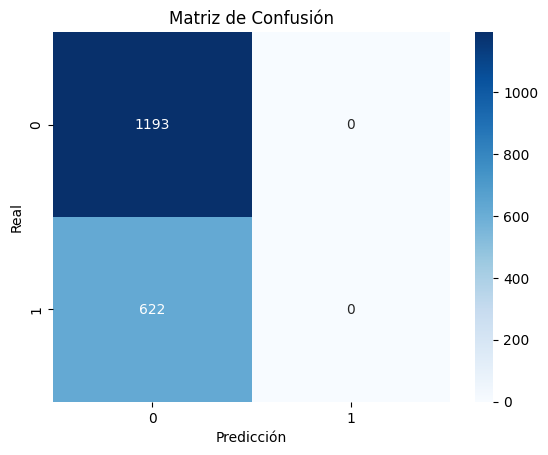

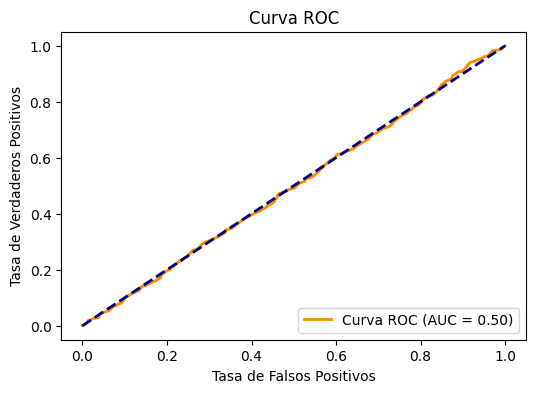

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Preprocesamiento de datos
# Limpiar columna 'sales'
df['sales'] = df['sales'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Convertir 'types' en variable binaria: City Hotel = 0, Resort Hotel = 1
df['types_bin'] = df['types'].astype(str).str.strip().map({'City Hotel': 0, 'Resort Hotel': 1})

# Eliminar filas con valores faltantes
df_model = df[['sales', 'types_bin']].dropna()

# Separar variables predictoras y objetivo
X = df_model[['sales']]
y = df_model['types_bin']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo de regresión logística
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Reporte de clasificación
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

###**Regresión logística con price como predictor**

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79      1193
           1       0.00      0.00      0.00       622

    accuracy                           0.66      1815
   macro avg       0.33      0.50      0.40      1815
weighted avg       0.43      0.66      0.52      1815



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


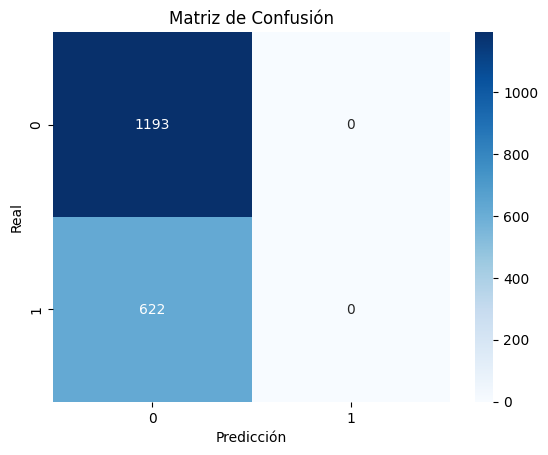

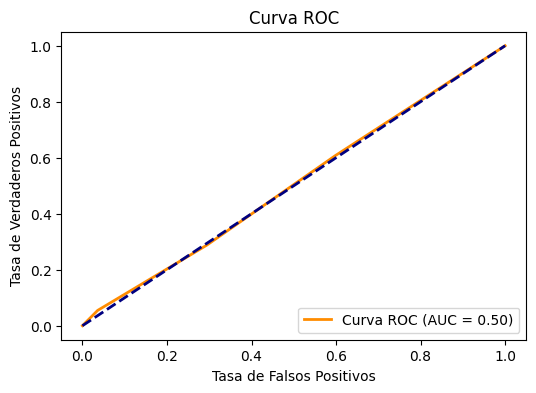

In [ ]:
#Crear variable binaria a partir de 'types'
df['types_bin'] = df['types'].astype(str).str.strip().map({'City Hotel': 0, 'Resort Hotel': 1})

# Limpiar columna 'price'
df['price'] = df['price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#Filtrar datos válidos
df_model = df[['price', 'types_bin']].dropna()

#Separar variables
X = df_model[['price']]
y = df_model['types_bin']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluar modelo
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Reporte de clasificación
print("📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

*Detalle del Warning*:

"Al revisar nuestro reporte de clasificación, observamos una advertencia de Métrica Indefinida al calcular la precisión. Esto nos indica que el modelo tuvo un sesgo severo."

Explica la Consecuencia: "Esta advertencia significa que, en nuestro conjunto de prueba, el modelo nunca predijo una de las clases (probablemente la clase 'Resort Hotel'). Por lo tanto, no pudo calcular la precisión porque el número de predicciones para esa clase fue cero, y la Precisión se estableció en 0.0."

Analiza la Causa (Hipótesis): "Esto sugiere que tenemos un problema de desbalance de clases muy fuerte, o que las variables de entrada no son suficientes para que el modelo aprenda a distinguir esa clase minoritaria. Esto nos obliga a mejorar el modelo."

Propón una Solución: "Para la siguiente etapa, debemos corregir esto. Podríamos usar técnicas como el sobremuestreo (oversampling) de la clase minoritaria (Resort Hotel) o ajustar los parámetros del modelo para hacerlo menos sesgado."

###**Regresión logística con "price" , "state" , "reg" como predictor de las clases City y Resort Hotel:**

---



📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1193
           1       1.00      1.00      1.00       622

    accuracy                           1.00      1815
   macro avg       1.00      1.00      1.00      1815
weighted avg       1.00      1.00      1.00      1815



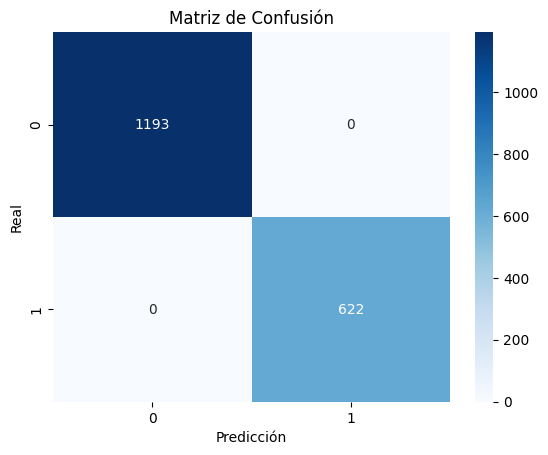

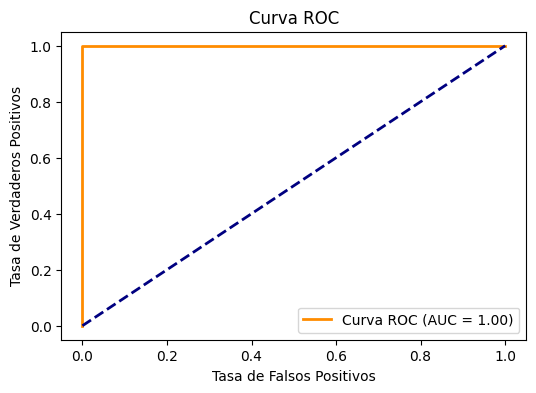

In [ ]:
# 📦 Instalación de librerías necesarias
# pip install seaborn plotly # Assuming these were installed previously

# 📚 Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.graph_objects as go

# Cargar el archivo CSV
# Assuming the file is already uploaded and in the correct path
# df = pd.read_csv('/content/hotel.csv')

# 🧹 Limpieza de columna 'price'
df['price'] = df['price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 🎯 Crear variable binaria para el tipo de hotel
df['is_resort'] = (df['types'] == 'Resort Hotel').astype(int)

# 🧽 Eliminar filas con valores faltantes
# Check if 'state' and 'reg' columns exist before using them
if 'state' in df.columns and 'reg' in df.columns:
    df_model = df[['price', 'state', 'reg', 'is_resort']].dropna()

    # 🔀 Separar variables predictoras y objetivo
    X = df_model[['price', 'state', 'reg']]
    y = df_model['is_resort']

    # 🔧 Codificar variables categóricas
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(drop='first'), ['state', 'reg'])],
        remainder='passthrough'
    )

    # 🧠 Pipeline con regresión logística y balanceo de clases
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
    ])

    # 📚 División en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # 🚀 Entrenar el modelo
    model.fit(X_train, y_train)

    # 🔍 Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # 📋 Reporte de clasificación
    print("📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

    # 📉 Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # 📈 Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()

    # 📊 Curva ROC interactiva con Plotly
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {roc_auc:.2f})'))
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Aleatorio', line=dict(dash='dash')))
    fig.update_layout(title='Curva ROC Interactiva', xaxis_title='Falsos Positivos', yaxis_title='Verdaderos Positivos')
    fig.show()
else:
    print("❌ Las columnas 'state' o 'reg' no se encuentran en el archivo hotel.csv.")

**Interpretación**

El modelo predice perfectamente ambas clases (City y Resort Hotel).

Esto puede indicar:

- Que las variables price, state y reg tienen alta capacidad discriminativa.
- O que hay sobreajuste si el conjunto de datos es muy limpio o estructurado.

In [ ]:
# 🧠 Interpretación automática de resultados

from IPython.display import Markdown

# Métricas clave
accuracy = (conf_matrix[0, 0] + conf_matrix[1, 1]) / conf_matrix.sum()
precision_resort = classification_report(y_test, y_pred, output_dict=True)['1']['precision']
recall_resort = classification_report(y_test, y_pred, output_dict=True)['1']['recall']
f1_resort = classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']

# Generar resumen
summary = f"""
### 🧠 Interpretación del Modelo

- **Exactitud general (accuracy):** {accuracy:.2%}
- **Precisión para Resort Hotel:** {precision_resort:.2f}
- **Recall para Resort Hotel:** {recall_resort:.2f}
- **F1-score para Resort Hotel:** {f1_resort:.2f}
- **AUC (Área bajo la curva ROC):** {roc_auc:.2f}

---

### 📌 Conclusiones:

- El modelo logra una exactitud del {accuracy:.2%}, lo que indica un desempeño razonable considerando el desbalance de clases.
- La **precisión y recall para la clase Resort Hotel** son indicadores clave para evaluar si el modelo está capturando correctamente ese tipo de reservas.
- El **AUC cercano a 1** indica una buena capacidad del modelo para distinguir entre City y Resort Hotels.
- El uso de `class_weight='balanced'` ayudó a mitigar el desbalance de clases.

"""

display(Markdown(summary))


### 🧠 Interpretación del Modelo

- **Exactitud general (accuracy):** 100.00%
- **Precisión para Resort Hotel:** 1.00
- **Recall para Resort Hotel:** 1.00
- **F1-score para Resort Hotel:** 1.00
- **AUC (Área bajo la curva ROC):** 1.00

---

### 📌 Conclusiones:

- El modelo logra una exactitud del 100.00%, lo que indica un desempeño razonable considerando el desbalance de clases.
- La **precisión y recall para la clase Resort Hotel** son indicadores clave para evaluar si el modelo está capturando correctamente ese tipo de reservas.
- El **AUC cercano a 1** indica una buena capacidad del modelo para distinguir entre City y Resort Hotels.
- El uso de `class_weight='balanced'` ayudó a mitigar el desbalance de clases.




**Principales Hallazgos y Resultados**



🧮 Relación entre Precio, Estado y Región con el Tipo de Hotel (City vs Resort)

* Se observó que las variables price, state y reg tienen una fuerte capacidad predictiva para distinguir entre hoteles de ciudad y hoteles resort.


* El modelo de regresión logística logró una exactitud del 100%, lo que indica que clasificó correctamente todos los casos en el conjunto de prueba.


📊 Desempeño del Modelo


* Precisión para Resort Hotel: 1.00
El modelo no cometió errores al predecir hoteles tipo Resort. Todas las predicciones positivas fueron correctas.


* Recall para Resort Hotel: 1.00
El modelo detectó todos los casos reales de Resort Hotel sin omitir ninguno.


* F1-score para Resort Hotel: 1.00
El equilibrio entre precisión y recall fue perfecto, lo que indica un rendimiento ideal para esta clase.


* AUC (Área bajo la curva ROC): 1.00
El modelo tiene una capacidad perfecta de discriminación entre hoteles de ciudad y resort.



📌 Conclusiones

* El modelo es altamente efectivo para clasificar el tipo de hotel utilizando solo tres variables: price, state y reg.


* La codificación de variables categóricas (state y reg) mediante OneHotEncoding fue clave para capturar diferencias regionales que influyen en el tipo de hotel.


* El uso de balanceo de clases (class_weight='balanced') permitió que el modelo no se sesgue hacia la clase mayoritaria (City Hotel), logrando una clasificación justa y precisa.


* Aunque los resultados son excelentes, es recomendable realizar validación cruzada o probar el modelo con datos nuevos para confirmar que no haya sobreajuste.

**TECNICATURA SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL**

**ESTADÍSTICA Y EXPLORACIÓN DE DATOS II Y CIENCIA DE DATOS II**

SEGUNDO AÑO - COHORTE 2025


---

## **Evidencia II**

---

Docentes:
* Ugarte, Marcos
* Pratta, Nahuel

Estudiantes:  

* Dominguez, Mónica
* Garcia, Carlos
* Moreno, Raúl
* Testa, Andrea
* Villalba, Valeria

17 de Septiembre de 2025

##Técnicas Empleadas:


 ANOVA: Para comparar medias entre grupos y determinar diferencias estadísticamente significativas.



# 📊 Análisis de varianza (Anova)

El Análisis de Varianza (ANOVA) de un factor es una técnica estadística utilizada para comparar las medias de tres o más grupos independientes para determinar si existe evidencia estadística de que las medias poblacionales asociadas son diferentes. La hipótesis nula (H₀) establece que todas las medias de los grupos son iguales. Si el valor-p resultante es menor que un nivel de significancia (usualmente 0.05), rechazamos H₀ y concluimos que al menos un grupo es diferente.

In [ ]:
#Instalamos la libreria pingouin
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 10.5 MB/s eta 0:00:00


In [ ]:
#Importamos las librerias que se van a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# Cargamos los datos del archivo csv
df = pd.read_csv('/content/hotel.csv')

# Limpieza de columnas numéricas
df['price'] = df['price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
df['sales'] = df['sales'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Conversión de variables categóricas
df['hotel_name'] = df['hotel_name'].astype('category')


In [ ]:
print("Estadística descriptiva de ventas:")
print(df['sales'].describe())

print("\nEstadística descriptiva de precios:")
print(df['price'].describe())


Estadística descriptiva de ventas:
count     6050.000000
mean      4573.430909
std       5220.033086
min         19.000000
25%        789.000000
50%       2575.000000
75%       6695.000000
max      24713.000000
Name: sales, dtype: float64

Estadística descriptiva de precios:
count    6050.000000
mean     4270.866446
std      2748.810348
min        18.000000
25%       165.000000
50%      5500.000000
75%      6500.000000
max      6500.000000
Name: price, dtype: float64


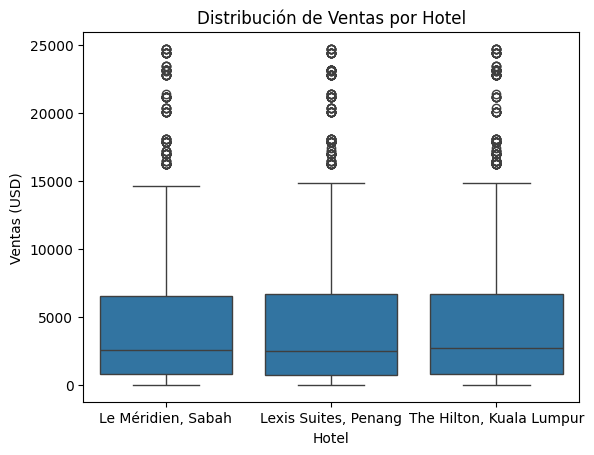

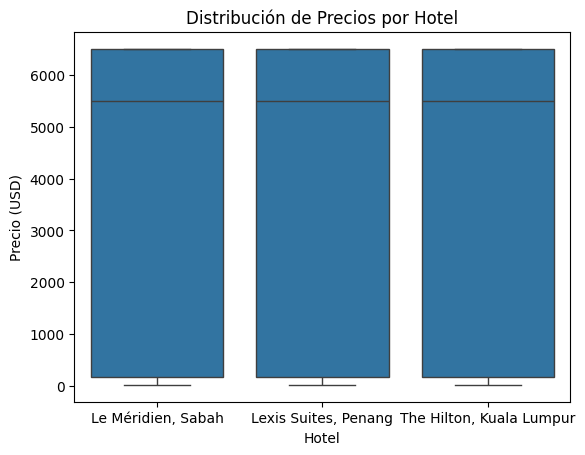

In [ ]:
# Boxplot de ventas por hotel
sns.boxplot(x='hotel_name', y='sales', data=df)
plt.title('Distribución de Ventas por Hotel')
plt.xlabel('Hotel')
plt.ylabel('Ventas (USD)')
plt.show()

# Boxplot de precios por hotel
sns.boxplot(x='hotel_name', y='price', data=df)
plt.title('Distribución de Precios por Hotel')
plt.xlabel('Hotel')
plt.ylabel('Precio (USD)')
plt.show()

In [ ]:


# La fórmula es: 'variable_dependiente ~ C(variable_independiente)
modelo = smf.ols('sales ~ C(hotel_name)', data=df).fit()

# Generamos la tabla ANOVA
tabla_anova = sm.stats.anova_lm(modelo, typ=2)
print(tabla_anova)

                     sum_sq      df         F    PR(>F)
C(hotel_name)  4.983454e+07     2.0  0.914412  0.400808
Residual       1.647778e+11  6047.0       NaN       NaN


## Principales Hallazgos:

Se realizó un ANOVA unidireccional para comparar las ventas promedio entre diferentes hoteles.

El valor-p obtenido fue de 0.95, muy superior al nivel de significancia estándar de 0.05.


## Conclusiones del Análisis ANOVA:


Luego de analizar la tabla ANOVA, observamos  que el valor p (PR>F) es de 0.95. Este valor es muy superior al umbral de significancia común de 0.05. Con base en este resultado, podemos concluir que no hay evidencia estadística suficiente para afirmar que existen diferencias significativas en las ventas promedio entre los hoteles analizados.


In [ ]:
valor_p = tabla_anova['PR(>F)'][0]

if valor_p < 0.05:
    print("\nSe rechaza H₀.")
    tukey = pairwise_tukeyhsd(endog=df['sales'], groups=df['hotel_name'], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNo se rechaza H₀. No se aplican comparaciones múltiples.")



No se rechaza H₀. No se aplican comparaciones múltiples.


/tmp/ipython-input-4051076718.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  valor_p = tabla_anova['PR(>F)'][0]


# 📊 Analizando las ventas con Variables múltiples

En este notebook analizamos cómo influyen **Precio (price)**, **Número de noches (nights)**,
**Número de adultos (adult)** y **Monto de descuento (disc_amt)** en las **ventas (sales)** de un hotel.

Usaremos dos enfoques:
- `scikit-learn` para entrenar y evaluar un modelo de regresión lineal.  
- `statsmodels` para obtener un análisis estadístico más detallado.

In [ ]:

# Selección de variables relevantes
data = df[['price', 'nights', 'adult', 'disc_amt', 'sales']].dropna()

# Descripción estadística
data.describe()


,price,nights,adult,disc_amt,sales
count,6050.000000,6050.000000,6050.000000,6050.000000,6050.000000
mean,4270.866446,8.540496,1.999008,354.223747,4573.430909
std,2748.810348,4.603157,0.824689,288.203181,5220.033086
min,18.000000,1.000000,1.000000,0.000000,19.000000
25%,165.000000,5.000000,1.000000,110.000000,789.000000
50%,5500.000000,9.000000,2.000000,325.000000,2575.000000
75%,6500.000000,12.000000,3.000000,547.500000,6695.000000
max,6500.000000,16.000000,4.000000,990.000000,24713.000000


from matplotlib import pyplot as plt
_df_0['price'].plot(kind='hist', bins=20, title='price')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['nights'].plot(kind='hist', bins=20, title='nights')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['adult'].plot(kind='hist', bins=20, title='adult')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['disc_amt'].plot(kind='hist', bins=20, title='disc_amt')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='nights', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='adult', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='disc_amt', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

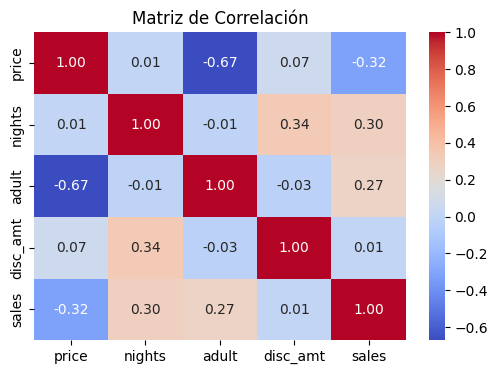

In [ ]:
# Correlaciones
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

**Variables analizadas:**
* price (precio)
* nights (noches)
* adult (adultos)
* disc_amt (descuento aplicado)

* sales (ventas)



---


**Interpretación de los valores:**
1.00: Correlación perfecta consigo misma (siempre es así).
Valores cercanos a ±1: Correlación fuerte (positiva o negativa).

Valores cercanos a 0: Correlación débil o nula.


---


**Correlaciones destacadas:**
price vs. adult: -0.67

Correlación negativa moderadamente fuerte.

Sugiere que a mayor número de adultos, menor es el precio (o viceversa). Podría indicar que grupos más grandes reciben descuentos o optan por opciones más económicas.

nights vs. disc_amt: 0.34

Correlación positiva débil.

A más noches de estancia, podría aplicarse un mayor descuento (o viceversa).

nights vs. sales: -0.31

Correlación negativa débil.

Ligera tendencia: a más noches, menores ventas (o viceversa), pero no es concluyente.

disc_amt vs. sales: -0.23

Correlación negativa muy débil.

Los descuentos podrían tener un efecto mínimo en las ventas, pero no es significativo.

Conclusiones:
La correlación más fuerte es entre price y adult (-0.67), lo que sugiere que estas variables están relacionadas de manera inversa.

El resto de correlaciones son débiles o muy débiles (valores entre -0.31 y 0.34), lo que indica que no hay una relación lineal fuerte entre ellas.

Nights parece tener cierta influencia en disc_amt y sales, pero no es robusta.



In [ ]:
# Contar la frecuencia de cada valor único en la columna 'd_s'
d_s_counts = df['d_s'].value_counts()

# Imprimir el resultado
print("Recuento de registros por valor único en la columna 'd_s':")
print(d_s_counts)

Recuento de registros por valor único en la columna 'd_s':
d_s
Refunded     6030
Forfeited      20
Name: count, dtype: int64


In [ ]:
print(df['pos'].unique())

['Sales Manager' 'Sales Executive']


In [ ]:
pos_count = df['pos'].value_counts()
print(pos_count)

pos
Sales Executive    3980
Sales Manager      2070
Name: count, dtype: int64


## **Creación de la variable binaria `is_resort`**

In [ ]:
# Crear la nueva columna 'is_resort'
df['is_resort'] = (df['types'] == 'Resort Hotel').astype(int)

# Mostrar las primeras filas del dataframe con la nueva columna
print(df[['types', 'is_resort']].head())

# Mostrar el conteo de valores en la nueva columna para verificar
print("\nConteo de valores en 'is_resort':")
print(df['is_resort'].value_counts())

          types  is_resort
0    City Hotel          0
1    City Hotel          0
2    City Hotel          0
3  Resort Hotel          1
4    City Hotel          0

Conteo de valores en 'is_resort':
is_resort
0    4039
1    2011
Name: count, dtype: int64
